In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd


dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

In [2]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

file = datafiles[0]

ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")

In [113]:
import numpy as np
import xarray as xr
from tqdm import tqdm

def coast_average_curvilinear_with_coord(ds, mask, lat, area, thickness=None,
                                          lat_cutoff=-60, y_dim="y", x_dim="x",
                                          dist_res_km=50.0):
    """
    Coast-centered average along Antarctic coastline for curvilinear grids.
    Adds distance-from-coast as a coordinate and interpolates to a regular grid.
    """

    nx = ds.sizes[x_dim]
    sum_weighted = None
    sum_weights = None
    regular_dist = None

    for xi in tqdm(range(nx), desc="Processing longitudes", unit="lon"):
        mask_section = mask.isel({x_dim: xi})
        lat_section = lat.isel({x_dim: xi})

        # --- Find first ocean cell along latitude
        ocean_cells = (mask_section == 1) & (lat_section < lat_cutoff)
        if not ocean_cells.any():
            continue

        j0 = int(ocean_cells.values.argmax())
        coast_lat = lat_section.isel({y_dim: j0}).values

        # --- Distance-from-coast for this section (km)
        dist_section = (lat_section - coast_lat) * 111.32  # degrees → km

        # Define regular distance grid once
        if regular_dist is None:
            max_dist_km = dist_section.max().values
            regular_dist = np.arange(0, max_dist_km + dist_res_km, dist_res_km)

        # --- Add distance as a coordinate
        section = ds.isel({x_dim: xi}).assign_coords({
            "dist_from_coast_km": (y_dim, dist_section.values)
        }).swap_dims({y_dim: "dist_from_coast_km"})

        area_section = area.isel({x_dim: xi}).assign_coords({
            "dist_from_coast_km": (y_dim, dist_section.values)
        }).swap_dims({y_dim: "dist_from_coast_km"})

        if thickness is not None:
            thickness_section = thickness.isel({x_dim: xi}).assign_coords({
                "dist_from_coast_km": (y_dim, dist_section.values)
            }).swap_dims({y_dim: "dist_from_coast_km"})
            weight_section = area_section * thickness_section
        else:
            weight_section = area_section

        # --- Interpolate to regular distance grid
        interp_section = section.interp(
            dist_from_coast_km=regular_dist,
            method="linear",
            kwargs={"fill_value": np.nan}
        )
        weight_interp_section = weight_section.interp(
            dist_from_coast_km=regular_dist,
            method="linear",
            kwargs={"fill_value": np.nan}
        )

        # --- Accumulate weighted sums
        if sum_weighted is None:
            sum_weighted = interp_section * weight_interp_section
            sum_weights = weight_interp_section
        else:
            sum_weighted = sum_weighted + interp_section * weight_interp_section
            sum_weights = sum_weights + weight_interp_section
        # return section, interp_section
    # --- Final weighted average
    coast_avg = sum_weighted / sum_weights
    coast_avg = coast_avg.assign_coords(dist_from_coast_km=regular_dist)

    return coast_avg.compute()


In [ ]:
tmp = coast_average_curvilinear_with_coord(ds, ds.wet > 0, ds.geolat, ds.areacello, thickness = ds.thkcello, y_dim = "yh", x_dim = "xh")

Processing longitudes: 100%|██████████| 240/240 [01:39<00:00,  2.40lon/s]


In [ ]:
tmp

In [ ]:
tmp[0].thetao.isel(time = 0).plot()

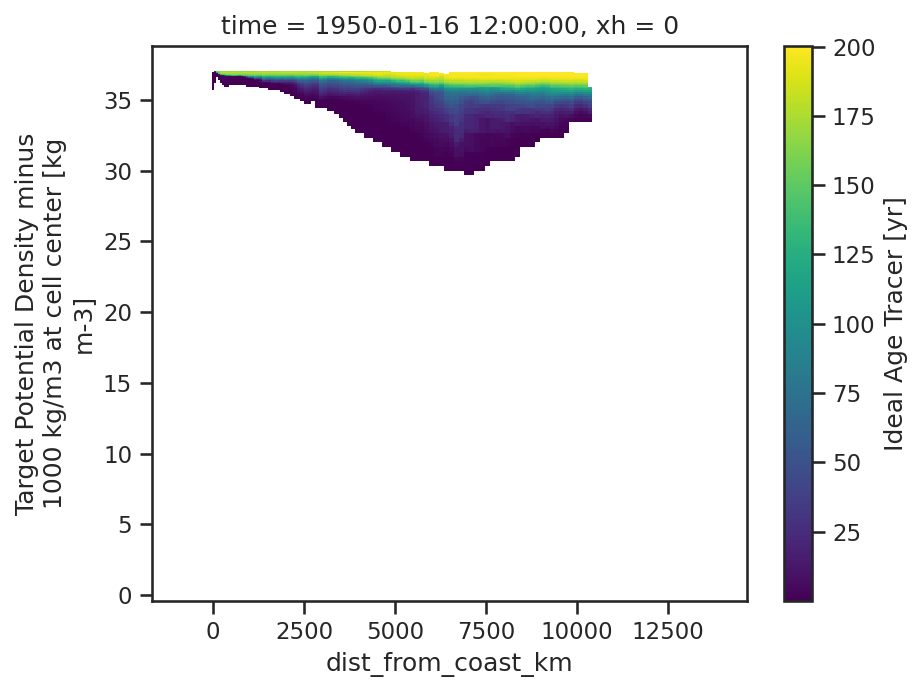

In [112]:
tmp[0].agessc.isel(time = 0).plot()

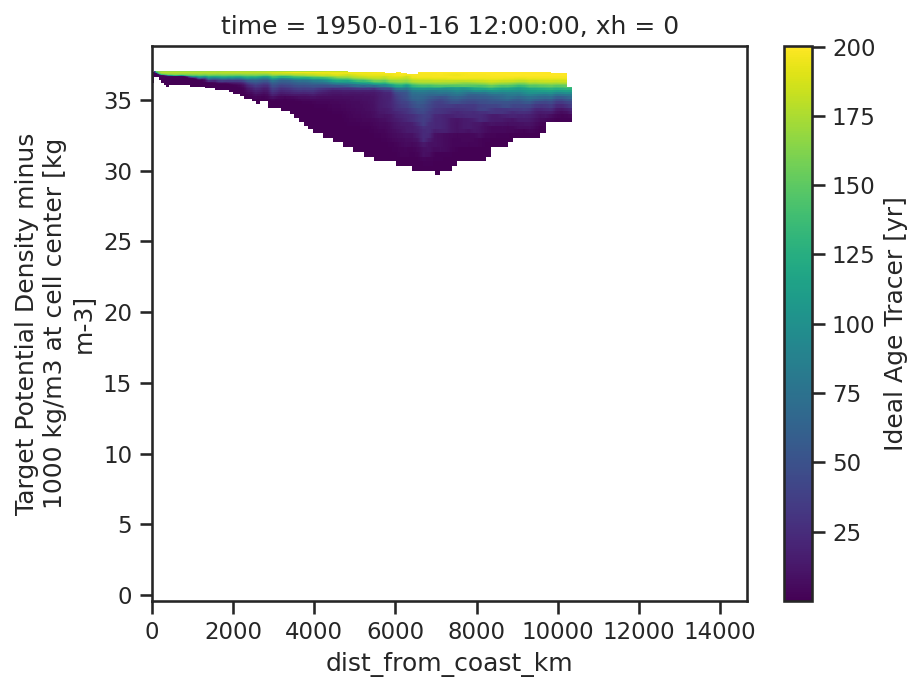

In [111]:
tmp[1].agessc.isel(time = 0).plot()

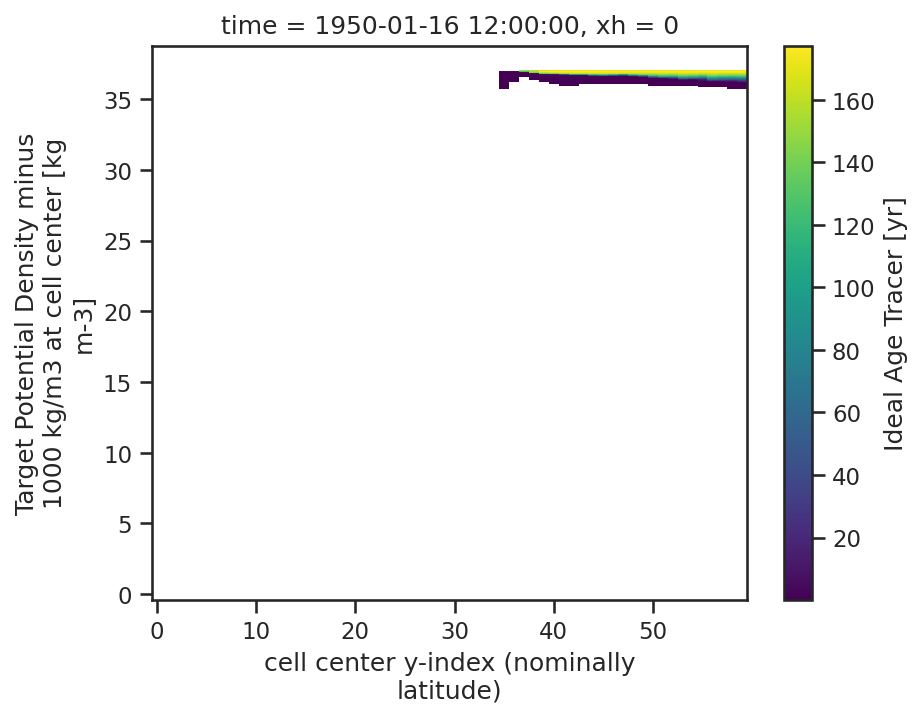

In [70]:
tmp[0].agessc.isel(time = 0).plot()

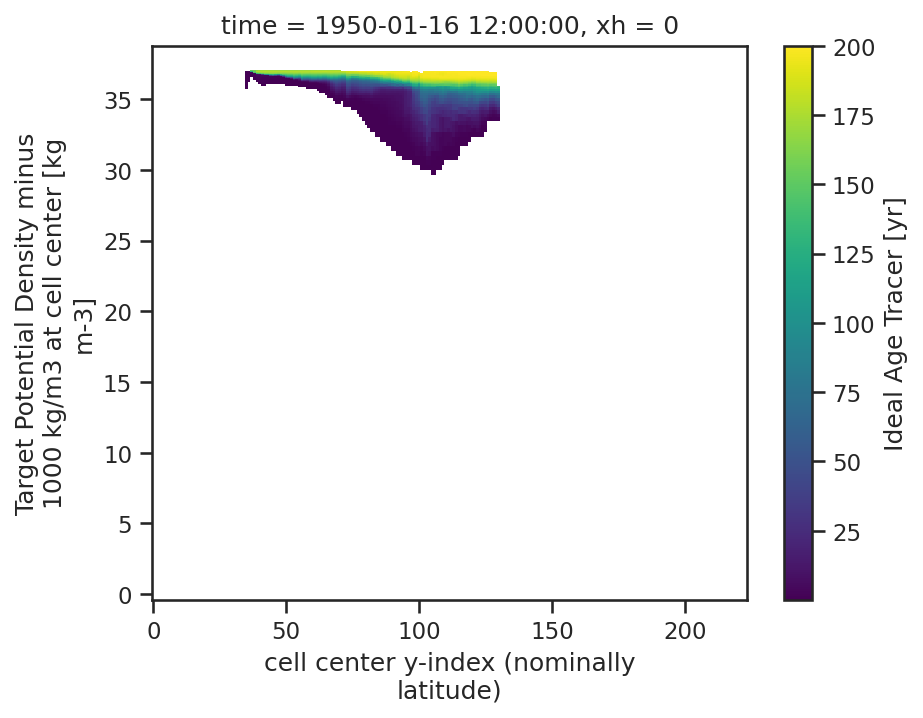

In [48]:
ds.agessc.isel(time = 0, xh = 0).plot()

In [64]:
tmp[0]

KeyError: "No variable named 0. Variables on the dataset include ['agessc', 'areacello', 'deptho', 'geolat', 'geolon', ..., 'sigma2_l', 'time', 'wet', 'xh', 'yh']"

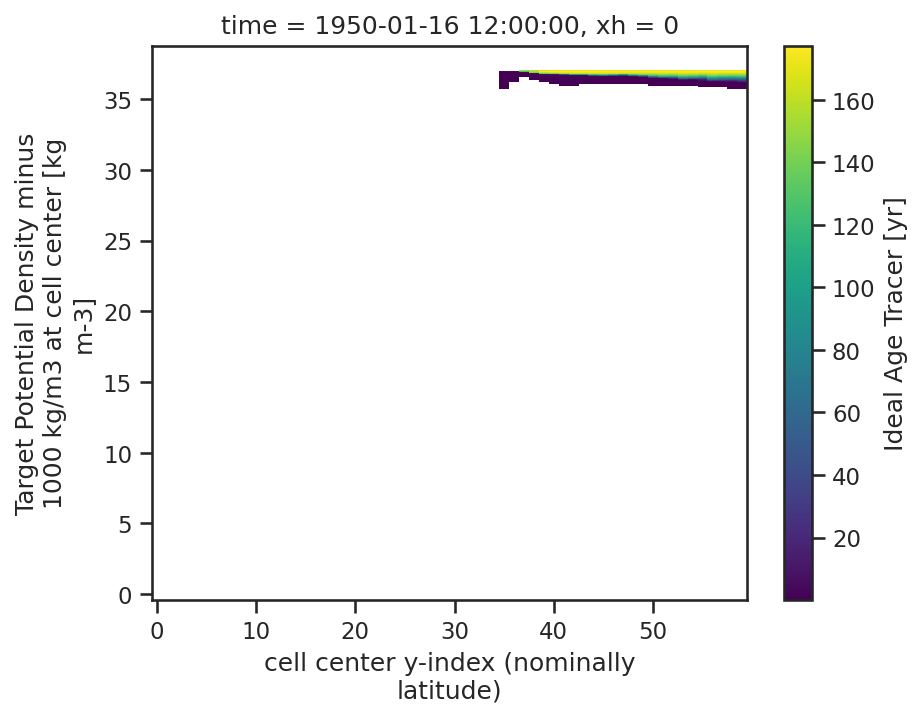

In [62]:
tmp.agessc.isel(time = 0).plot()